# Лабораторна 5 — Багатошаровий перцептрон (WineQT)
Реалізація MLP з нуля та порівняння з PyTorch на датасеті WineQT.

**ВАЖЛИВО:** Код не використовує `tensor.numpy()`, щоб уникнути помилки `RuntimeError: Numpy is not available` з PyTorch.

In [ ]:

# ІМПОРТ БІБЛІОТЕК ТА НАЛАШТУВАННЯ

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
%matplotlib inline

# Вибір CPU або GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Використовуємо девайс:", device)

# Фіксуємо зерно випадковості
torch.manual_seed(42)
np.random.seed(42)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/py

Використовуємо девайс: cpu


In [ ]:

#  ПІДГОТОВКА ДАНИХ (WineQT.csv)
# Читаємо WineQT.csv з твого шляху, прибираємо Id,очищає дані, кодує класи, масштабує ознаки,
# ділимо на train/val/test, масштабуємо, перетворюємо в тензори.

def load_and_preprocess_data(csv_path="/Users/svelebasergij/Desktop/мн_5/WineQT.csv"):
    df = pd.read_csv(csv_path)

    # Видаляємо колонку Id
    if "Id" in df.columns:
        df = df.drop(columns=["Id"])

    print("Перші рядки датафрейму:")
    display(df.head())

    # Цільова змінна
    y = df["quality"].values
    X = df.drop(columns=["quality"]).values

    # Класи якості у 0..K-1
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    class_names = [str(c) for c in label_encoder.classes_]
    num_classes = len(class_names)
    print("Класи якості:", class_names)

    # Train/Val/Test = 60/20/20
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
    )

    print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

    # Масштабування ознак
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    # У тензори
    X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
    X_val_t   = torch.tensor(X_val,   dtype=torch.float32, device=device)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32, device=device)

    y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long, device=device)
    y_test_t  = torch.tensor(y_test,  dtype=torch.long, device=device)

    input_size = X_train.shape[1]

    return X_train_t, X_val_t, X_test_t, y_train_t, y_val_t, y_test_t, input_size, num_classes, class_names


X_train, X_val, X_test, y_train, y_val, y_test, input_size, num_classes, class_names =         load_and_preprocess_data()

print("Розмірність входу:", input_size, "| Кількість класів:", num_classes)


Перші рядки датафрейму:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Класи якості: ['3', '4', '5', '6', '7', '8']
Train: (685, 11) Val: (229, 11) Test: (229, 11)
Розмірність входу: 11 | Кількість класів: 6


In [ ]:

# ФУНКЦІЇ АКТИВАЦІЇ 


class ActivationFunctions:

    @staticmethod
    def relu(x, derivative=False): #допомагає моделі швидше та краще навчатися.
        """ReLU: f(x) = max(0, x)"""
        if derivative:
            return (x > 0).float()
        return torch.clamp(x, min=0)

    @staticmethod
    def tanh(x, derivative=False):#робить дані більш збалансованими і часто покращує навчання.

        """Tanh: f(x) = tanh(x)"""
        if derivative:
            return 1.0 - torch.tanh(x) ** 2
        return torch.tanh(x)


In [ ]:


# ФУНКЦІЯ ВТРАТ наскільки моделі помиляється
#Цей код реалізує функцію втрат та її похідну
class LossFunctions:

    @staticmethod
    def categorical_cross_entropy(y_pred_logits, y_true, derivative=False):
        """
        y_pred_logits: логіти (batch_size, num_classes)
        y_true: індекси справжніх класів (batch_size,)
        """
        batch_size = y_true.shape[0]

        if not derivative:
            # log_softmax + NLL для стабільності
            log_probs = F.log_softmax(y_pred_logits, dim=1)
            loss = F.nll_loss(log_probs, y_true, reduction="mean")
            return loss

        # Похідна dL/dz для softmax + cross-entropy
        probs = F.softmax(y_pred_logits, dim=1)
        num_classes = probs.shape[1]
        y_one_hot = F.one_hot(y_true, num_classes=num_classes).float()
        grad = (probs - y_one_hot) / batch_size
        return grad


In [ ]:

# ВЛАСНА РЕАЛІЗАЦІЯ MLP (CustomMLP)
#Клас CustomMLP реалізує багатошарову нейронну мережу, створену повністю вручну
#Він самостійно виконує ініціалізацію ваг, прямий прохід (forward), обчислення втрат, зворотне поширення помилки (backpropagation)
# розрахунок градієнтів і оновлення ваг

class CustomMLP:
    def __init__(self, layer_sizes, activations, learning_rate=0.01):
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.learning_rate = learning_rate
        self.num_layers = len(layer_sizes) - 1
        self.parameters = {}
        self._init_params()

    def _init_params(self):
        # Xavier-ініціалізація ваг
        for i in range(1, len(self.layer_sizes)):
            in_dim = self.layer_sizes[i - 1]
            out_dim = self.layer_sizes[i]
            limit = np.sqrt(2.0 / (in_dim + out_dim))
            W = torch.randn(in_dim, out_dim, device=device) * limit
            b = torch.zeros(1, out_dim, device=device)
            self.parameters[f"W{i}"] = W
            self.parameters[f"b{i}"] = b

    def _get_activation(self, name):
        if name == "relu":
            return ActivationFunctions.relu
        elif name == "tanh":
            return ActivationFunctions.tanh
        else:
            raise ValueError(f"Невідома активація: {name}")

    def forward(self, X):
        A = X
        cache = {"A0": A}

        for i in range(1, self.num_layers + 1):
            W = self.parameters[f"W{i}"]
            b = self.parameters[f"b{i}"]
            Z = A @ W + b

            if i <= len(self.activations):  # приховані шари
                act_name = self.activations[i - 1]
                act_func = self._get_activation(act_name)
                A = act_func(Z)
            else:
                # вихідний шар: просто логіти
                A = Z

            cache[f"Z{i}"] = Z
            cache[f"A{i}"] = A

        logits = A
        return logits, cache

    def backward(self, X, y, cache):
        L = self.num_layers
        logits = cache[f"A{L}"]

        # Втрати
        loss = LossFunctions.categorical_cross_entropy(logits, y, derivative=False)

        # dL/dz вихідного шару
        dZ = LossFunctions.categorical_cross_entropy(logits, y, derivative=True)

        grads_W = {}
        grads_b = {}

        # Вихідний шар
        A_prev = cache[f"A{L-1}"]
        grads_W[f"W{L}"] = A_prev.T @ dZ
        grads_b[f"b{L}"] = dZ.sum(dim=0, keepdim=True)
        dA_prev = dZ @ self.parameters[f"W{L}"].T

        # Приховані шари
        for i in range(L - 1, 0, -1):
            Z_i = cache[f"Z{i}"]
            A_prev = cache[f"A{i-1}"]
            W_i = self.parameters[f"W{i}"]

            act_name = self.activations[i - 1]
            act_func = self._get_activation(act_name)
            d_act = act_func(Z_i, derivative=True)

            dZ_i = dA_prev * d_act
            grads_W[f"W{i}"] = A_prev.T @ dZ_i
            grads_b[f"b{i}"] = dZ_i.sum(dim=0, keepdim=True)

            dA_prev = dZ_i @ W_i.T

        # Оновлення ваг
        with torch.no_grad():
            for i in range(1, L + 1):
                self.parameters[f"W{i}"] -= self.learning_rate * grads_W[f"W{i}"]
                self.parameters[f"b{i}"] -= self.learning_rate * grads_b[f"b{i}"]

        return loss.item()

    def predict(self, X):
        with torch.no_grad():
            logits, _ = self.forward(X)
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
        return preds


In [ ]:

#  ДОПОМІЖНІ ФУНКЦІЇ ДЛЯ ТОЧНОСТІ 

def accuracy_from_tensors(y_true_tensor, y_pred_tensor):
    """Рахуємо accuracy, перетворюючи tensори у списки, а не у .numpy()."""
    y_true_list = y_true_tensor.detach().cpu().tolist()
    y_pred_list = y_pred_tensor.detach().cpu().tolist()
    return accuracy_score(y_true_list, y_pred_list)


In [ ]:

#  НАВЧАННЯ ВЛАСНОГО MLP (CustomMLP)
#Код виконує повний цикл навчання нашої нейронної мережі: прямий прохід, зворотне поширення, оновлення ваг, 
# обчислення точності та оцінку на тестових даних.

def train_custom_mlp(model, X_train, y_train, X_val, y_val, epochs=200):
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        # TRAIN
        logits_train, cache = model.forward(X_train)
        train_loss = model.backward(X_train, y_train, cache)
        preds_train = model.predict(X_train)
        train_acc = accuracy_from_tensors(y_train, preds_train)

        # VAL
        with torch.no_grad():
            logits_val, _ = model.forward(X_val)
            val_loss = LossFunctions.categorical_cross_entropy(
                logits_val, y_val, derivative=False
            ).item()
            preds_val = model.predict(X_val)
            val_acc = accuracy_from_tensors(y_val, preds_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if epoch % 20 == 0 or epoch == 1:
            print(
                f"[Custom] Epoch {epoch:3d} | "
                f"Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f} | "
                f"Train acc: {train_acc:.3f}, Val acc: {val_acc:.3f}"
            )

    return history


# Створюємо модель
hidden_sizes = [64, 32]
layer_sizes = [input_size] + hidden_sizes + [num_classes]
activations = ["relu", "relu"]

custom_mlp = CustomMLP(layer_sizes, activations, learning_rate=0.01)

# Навчання
history_custom = train_custom_mlp(custom_mlp, X_train, y_train, X_val, y_val, epochs=200)

# Оцінка на тесті
test_preds_custom = custom_mlp.predict(X_test)
test_acc_custom = accuracy_from_tensors(y_test, test_preds_custom)
print(f"Custom MLP | Test accuracy: {test_acc_custom:.3f}")


[Custom] Epoch   1 | Train loss: 1.7124, Val loss: 1.6826 | Train acc: 0.295, Val acc: 0.336
[Custom] Epoch  20 | Train loss: 1.5989, Val loss: 1.5674 | Train acc: 0.429, Val acc: 0.410
[Custom] Epoch  40 | Train loss: 1.5010, Val loss: 1.4682 | Train acc: 0.477, Val acc: 0.467
[Custom] Epoch  60 | Train loss: 1.4225, Val loss: 1.3897 | Train acc: 0.491, Val acc: 0.524
[Custom] Epoch  80 | Train loss: 1.3601, Val loss: 1.3282 | Train acc: 0.504, Val acc: 0.537
[Custom] Epoch 100 | Train loss: 1.3109, Val loss: 1.2802 | Train acc: 0.540, Val acc: 0.546
[Custom] Epoch 120 | Train loss: 1.2714, Val loss: 1.2423 | Train acc: 0.550, Val acc: 0.555
[Custom] Epoch 140 | Train loss: 1.2393, Val loss: 1.2120 | Train acc: 0.549, Val acc: 0.563
[Custom] Epoch 160 | Train loss: 1.2129, Val loss: 1.1873 | Train acc: 0.553, Val acc: 0.559
[Custom] Epoch 180 | Train loss: 1.1905, Val loss: 1.1669 | Train acc: 0.555, Val acc: 0.568
[Custom] Epoch 200 | Train loss: 1.1707, Val loss: 1.1492 | Train acc:

In [ ]:

#  PyTorch-MLP ДЛЯ ПОРІВНЯННЯ 
# Цей код створює та навчає нейронну мережу в PyTorch, щоб порівняти її роботу з нашою власноруч реалізованою моделлю CustomMLP.

class PyTorchMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super().__init__()
        layers = []
        prev_dim = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_pytorch_model(model, X_train, y_train, X_val, y_val, epochs=200):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters())

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits_train = model(X_train)
        loss_train = criterion(logits_train, y_train)
        loss_train.backward()
        optimizer.step()

        preds_train = torch.argmax(logits_train, dim=1)
        train_acc = accuracy_from_tensors(y_train, preds_train)

        model.eval()
        with torch.no_grad():
            logits_val = model(X_val)
            loss_val = criterion(logits_val, y_val)
            preds_val = torch.argmax(logits_val, dim=1)
            val_acc = accuracy_from_tensors(y_val, preds_val)

        history["train_loss"].append(loss_train.item())
        history["val_loss"].append(loss_val.item())
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if epoch % 20 == 0 or epoch == 1:
            print(
                f"[PyTorch] Epoch {epoch:3d} | "
                f"Train loss: {loss_train.item():.4f}, Val loss: {loss_val.item():.4f} | "
                f"Train acc: {train_acc:.3f}, Val acc: {val_acc:.3f}"
            )

    return history


pytorch_mlp = PyTorchMLP(input_size, hidden_sizes, num_classes).to(device)
history_pytorch = train_pytorch_model(pytorch_mlp, X_train, y_train, X_val, y_val, epochs=200)

# Оцінка на тесті
pytorch_mlp.eval()
with torch.no_grad():
    logits_test_pt = pytorch_mlp(X_test)
    preds_test_pt = torch.argmax(logits_test_pt, dim=1)
    test_acc_pt = accuracy_from_tensors(y_test, preds_test_pt)

print(f"PyTorch MLP | Test accuracy: {test_acc_pt:.3f}")


[PyTorch] Epoch   1 | Train loss: 1.8557, Val loss: 1.8393 | Train acc: 0.101, Val acc: 0.135
[PyTorch] Epoch  20 | Train loss: 1.5169, Val loss: 1.4909 | Train acc: 0.428, Val acc: 0.437
[PyTorch] Epoch  40 | Train loss: 1.2227, Val loss: 1.1966 | Train acc: 0.458, Val acc: 0.472
[PyTorch] Epoch  60 | Train loss: 1.0972, Val loss: 1.0702 | Train acc: 0.553, Val acc: 0.585
[PyTorch] Epoch  80 | Train loss: 1.0239, Val loss: 1.0051 | Train acc: 0.572, Val acc: 0.616
[PyTorch] Epoch 100 | Train loss: 0.9748, Val loss: 0.9727 | Train acc: 0.590, Val acc: 0.616
[PyTorch] Epoch 120 | Train loss: 0.9365, Val loss: 0.9551 | Train acc: 0.609, Val acc: 0.638
[PyTorch] Epoch 140 | Train loss: 0.9038, Val loss: 0.9505 | Train acc: 0.623, Val acc: 0.629
[PyTorch] Epoch 160 | Train loss: 0.8755, Val loss: 0.9491 | Train acc: 0.635, Val acc: 0.620
[PyTorch] Epoch 180 | Train loss: 0.8504, Val loss: 0.9488 | Train acc: 0.651, Val acc: 0.620
[PyTorch] Epoch 200 | Train loss: 0.8269, Val loss: 0.9508 |

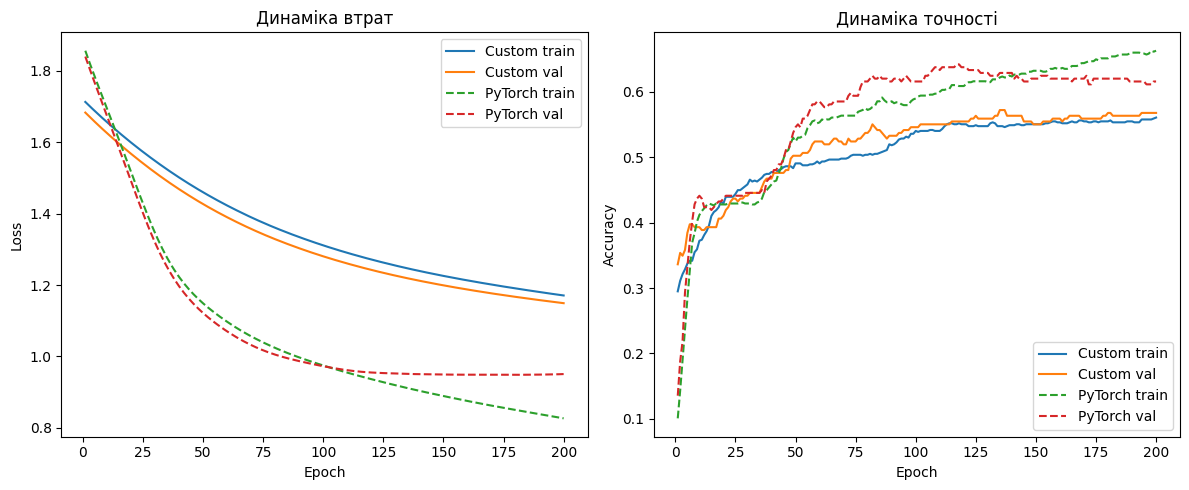

In [ ]:

# ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ
# Цей код будує графіки втрат і точності по епохах для Custom MLP та PyTorch MLP, що дозволяє наочно порівняти їхню швидкість навчання та якість.

def plot_training_history(history_custom, history_pytorch):
    epochs = range(1, len(history_custom["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_custom["train_loss"], label="Custom train")
    plt.plot(epochs, history_custom["val_loss"], label="Custom val")
    plt.plot(epochs, history_pytorch["train_loss"], "--", label="PyTorch train")
    plt.plot(epochs, history_pytorch["val_loss"], "--", label="PyTorch val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Динаміка втрат")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_custom["train_acc"], label="Custom train")
    plt.plot(epochs, history_custom["val_acc"], label="Custom val")
    plt.plot(epochs, history_pytorch["train_acc"], "--", label="PyTorch train")
    plt.plot(epochs, history_pytorch["val_acc"], "--", label="PyTorch val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Динаміка точності")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_training_history(history_custom, history_pytorch)
#PyTorch-модель навчається швидше, має нижчу помилку та вищу точність, ніж наша власна реалізація MLP


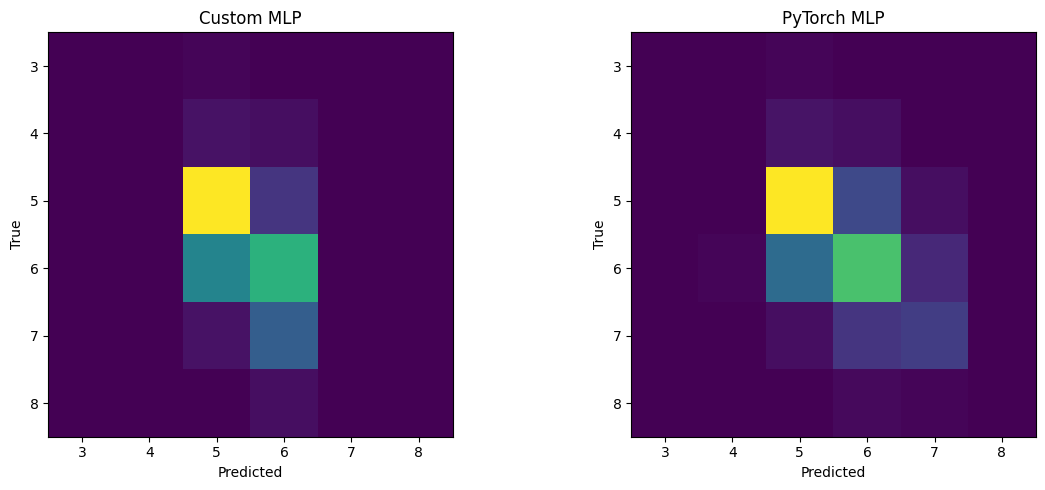

In [ ]:

# Матриці змішування для обох моделей

y_true_list = y_test.detach().cpu().tolist()
y_pred_custom_list = test_preds_custom.detach().cpu().tolist()
y_pred_pytorch_list = preds_test_pt.detach().cpu().tolist()

cm_custom = confusion_matrix(y_true_list, y_pred_custom_list)
cm_pytorch = confusion_matrix(y_true_list, y_pred_pytorch_list)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
im1 = ax.imshow(cm_custom)
ax.set_title("Custom MLP")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

ax = axes[1]
im2 = ax.imshow(cm_pytorch)
ax.set_title("PyTorch MLP")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

plt.tight_layout()
plt.show()


In [ ]:
 #Вони показують, які оцінки вина модель вгадує правильно, а які плутає.
#Custom MLP — наша власноруч написана
#PyTorch MLP — стандартна модель PyTorch